# IR Spectroscopy of Everyday Materials

Fourier-transform infrared (FT-IR) spectroscopy identifies the polar covalent bonds in a material by measuring which infrared frequencies it absorbs. Different functional groups — O-H, C=O, C-H, N-H, and others — vibrate at characteristic frequencies, producing a unique absorption fingerprint for each compound.

This survey of 23 household and laboratory samples uses the Thermo Scientific Nicolet 380 FT-IR Spectrometer in ATR mode (550–4,000 cm⁻¹). In ATR mode, an infrared beam reflects internally within the crystal and an evanescent wave penetrates a few microns into the sample surface, so samples can be measured as-is without any preparation. Raw CSVs were exported from Thermo Scientific OMNIC 8.

## 1. Setup

Import libraries, define the sample index, and set up functional group annotation regions used across all plots.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, os
from scipy.signal import find_peaks

LOCAL = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'scrubbed')
GITHUB = 'https://raw.githubusercontent.com/vivianweidai/science/main/research/projects/20260415%20IR%20Spectroscopy/output/scrubbed'
SAVE = os.path.exists('images')

def load(name):
    local = os.path.join(LOCAL, f'{name}.csv')
    return pd.read_csv(local) if os.path.exists(local) else pd.read_csv(f'{GITHUB}/{name}.csv')

def save(path):
    if SAVE:
        plt.savefig(path, dpi=300, bbox_inches='tight')

REGIONS = [
    (3200, 3600, 'O–H stretch', '#cce5ff'),
    (2850, 3000, 'C–H stretch', '#d4edda'),
    (1680, 1750, 'C=O stretch', '#f8d7da'),
    (1600, 1680, 'C=C stretch', '#fff3cd'),
    (1350, 1480, 'C–H bend',    '#fce4b8'),
    (1000, 1300, 'C–O stretch', '#e2d9f3'),
]

COLORS = ['#d95f5f', '#5b9bd5', '#70ad47', '#ed7d31', '#9b59b6', '#e6a532', '#888888']

def annotate(ax):
    for lo, hi, label, color in REGIONS:
        ax.axvspan(lo, hi, alpha=0.35, color=color, zorder=0)
        ax.text((lo+hi)/2, ax.get_ylim()[1]*0.95, label,
                ha='center', va='top', fontsize=7, rotation=90, color='#555')

def fmt(ax):
    ax.set_xlim(4000, 550)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
    ax.set_ylabel('Absorbance')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

print('Setup complete.')

Setup complete.


## 2. Acetone — Prototype Spectrum

Acetone is an ideal first sample — its spectrum has a sharp, unmistakable C=O carbonyl peak at ~1,715 cm⁻¹ and clean C–H stretches around 3,000 cm⁻¹. Shaded regions highlight the five main functional group zones.

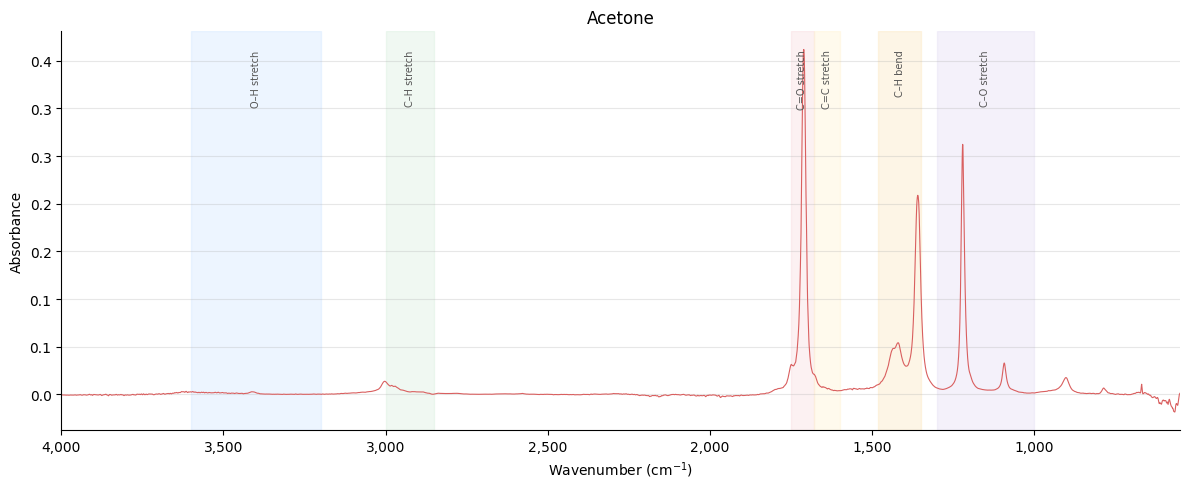

In [2]:
acetone = load('acetone')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(acetone['wavenumber'], acetone['absorbance'], color='#d95f5f', linewidth=0.8)
annotate(ax)
fmt(ax)
ax.set_title('Acetone')
plt.tight_layout()
save('images/acetone_spectrum.png')
plt.show()

## 3. Acetone — Peak Identification

Automatic peak detection using `scipy.signal.find_peaks` to locate the strongest absorptions, then match each peak to a known functional group assignment for acetone. Key features:

- **~1,715 cm⁻¹** — C=O carbonyl stretch, the dominant peak and most characteristic absorption in ketones
- **~2,950–3,000 cm⁻¹** — C–H stretching of the two methyl groups
- **~1,350–1,450 cm⁻¹** — C–H bending (symmetric and asymmetric scissoring of CH₃)
- **~1,000–1,300 cm⁻¹** — C–O and C–C skeletal stretches in the fingerprint region
- **No broad O–H band** around 3,200–3,600 cm⁻¹, confirming the sample is anhydrous

In [3]:
peaks, _ = find_peaks(acetone['absorbance'], height=0.02, prominence=0.01, distance=50)

peak_df = pd.DataFrame({
    'wavenumber': acetone['wavenumber'].iloc[peaks].values,
    'absorbance': acetone['absorbance'].iloc[peaks].values,
}).sort_values('absorbance', ascending=False).head(10)

ASSIGNMENTS = {
    (1700, 1730): 'C=O stretch (carbonyl)',
    (1350, 1380): 'C–H bend (symmetric)',
    (1410, 1440): 'C–H bend (asymmetric)',
    (1210, 1240): 'C–C stretch',
    (2950, 3010): 'C–H stretch (methyl)',
    (530, 570):   'C–C=O bend',
}

def assign(wn):
    for (lo, hi), label in ASSIGNMENTS.items():
        if lo <= wn <= hi:
            return label
    return ''

peak_df['assignment'] = peak_df['wavenumber'].apply(assign)
print(peak_df.to_string(index=False))

 wavenumber  absorbance             assignment
   1710.068    0.361884 C=O stretch (carbonyl)
   1220.237    0.262278            C–C stretch
   1358.605    0.208806   C–H bend (symmetric)
   1419.352    0.054102  C–H bend (asymmetric)
   1091.994    0.032816                       


## 4. Representative Spectra

Four more samples chosen to illustrate contrasting IR signatures: water (broad O–H), salt (ionic — nearly flat), plastic bag (pure C–H), and sugar (rich O–H plus C–O fingerprint).

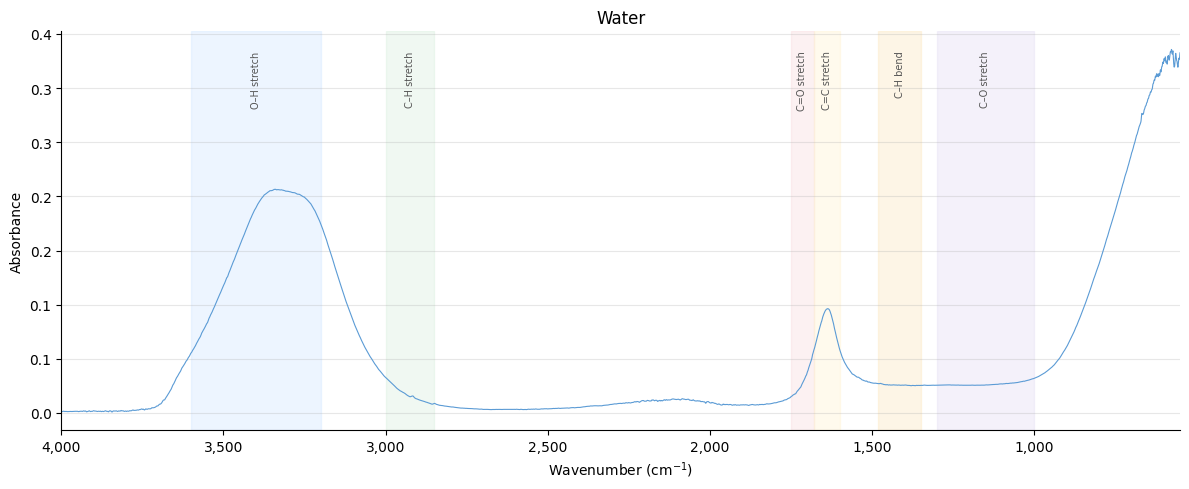

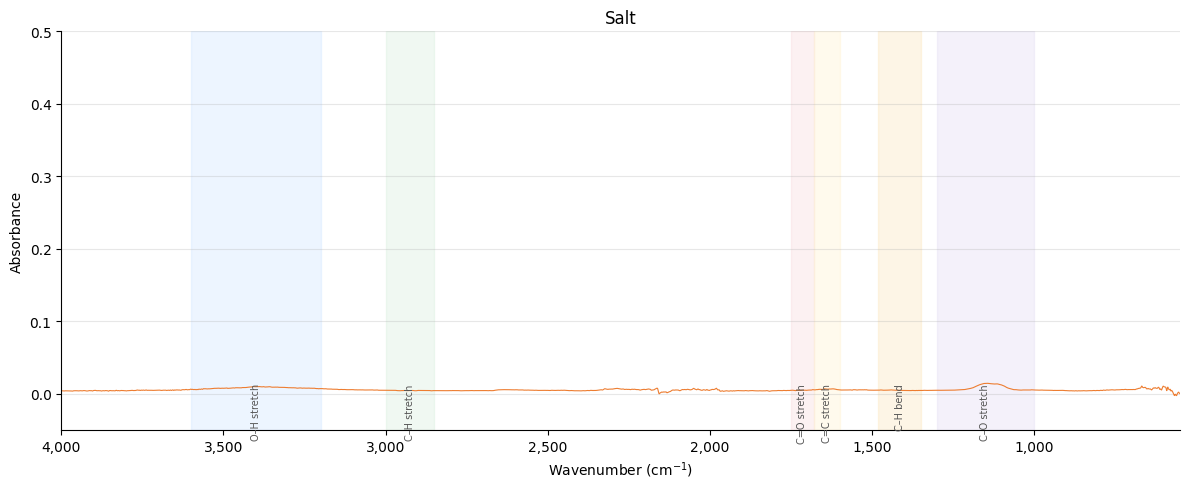

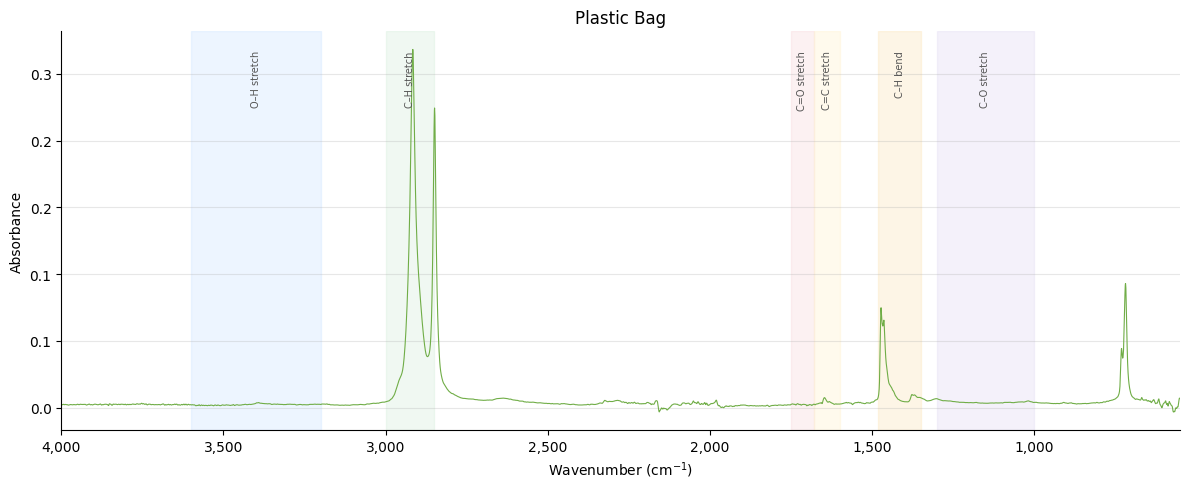

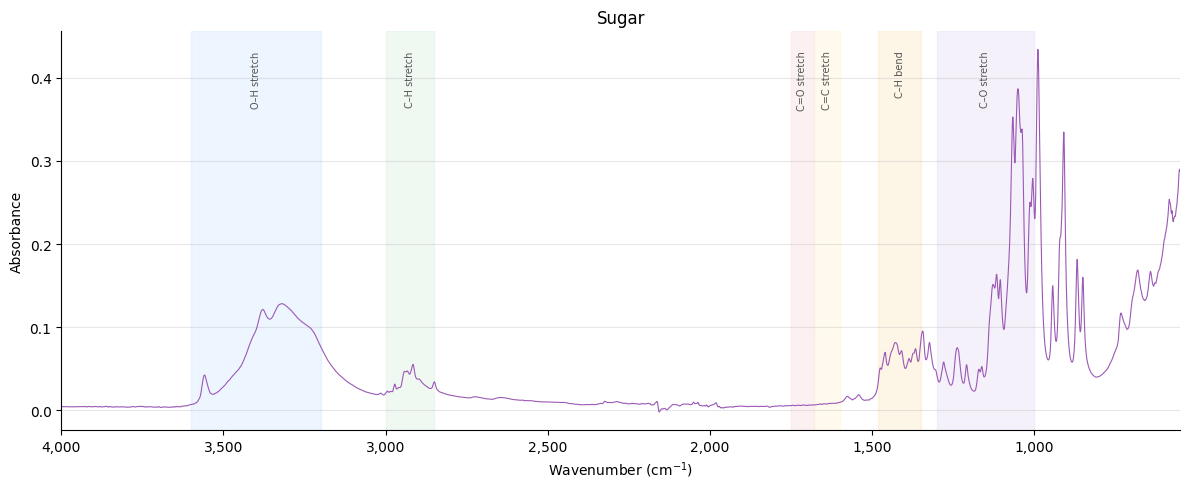

In [4]:
reps = {'Water': ('water', '#5b9bd5'), 'Salt': ('salt', '#ed7d31'),
        'Plastic Bag': ('plastic_bag', '#70ad47'), 'Sugar': ('sugar', '#9b59b6')}

for title, (name, color) in reps.items():
    s = load(name)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s['wavenumber'], s['absorbance'], color=color, linewidth=0.8)
    annotate(ax)
    fmt(ax)
    if name == 'salt':
        ax.set_ylim(-0.05, 0.5)
    ax.set_title(title)
    plt.tight_layout()
    save(f'images/{name}_spectrum.png')
    plt.show()

## 5. Household Categories

Overlay spectra grouped by where you'd find them around the house — solvents, food, personal care products, plastics, paper, and biological samples.

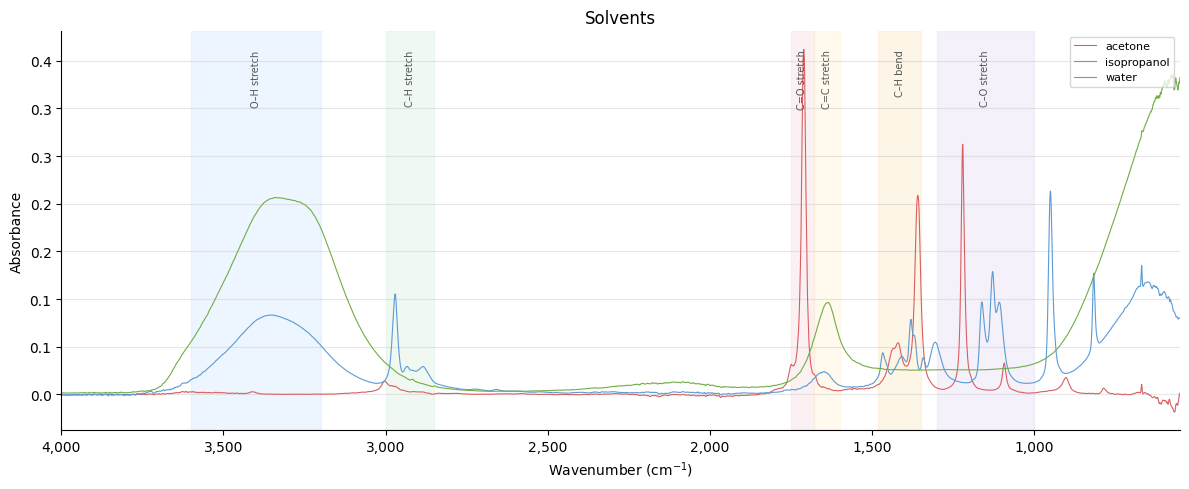

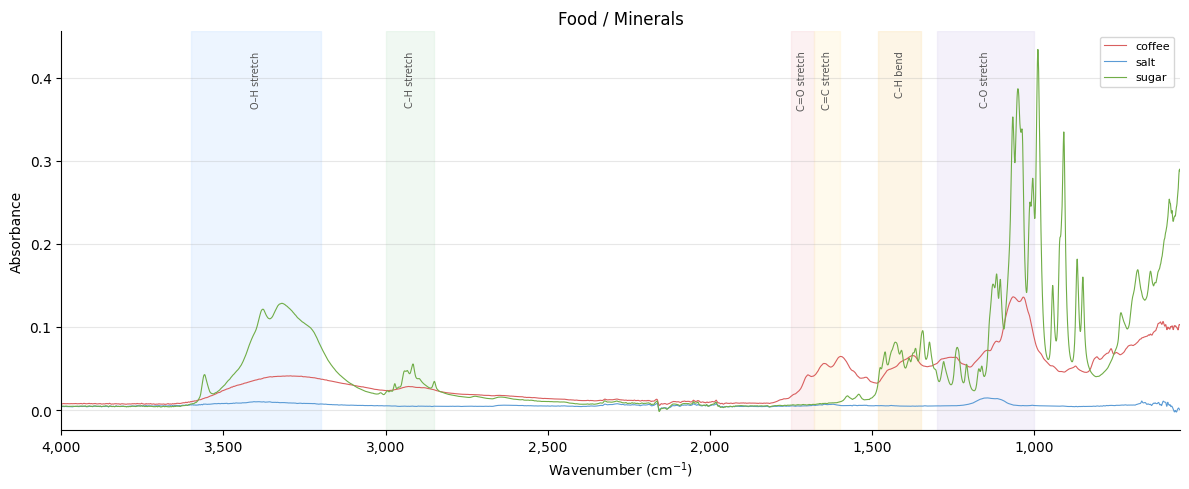

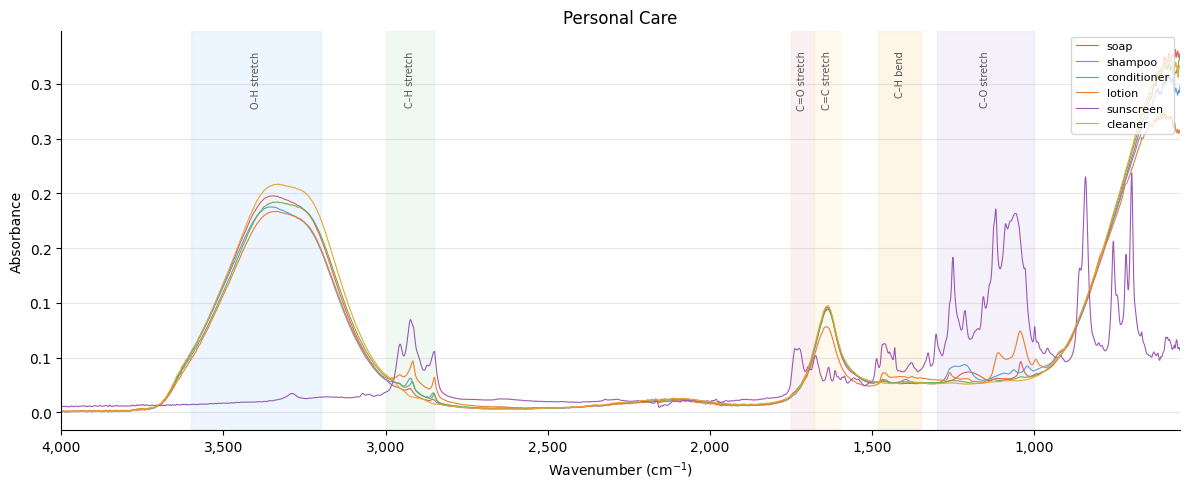

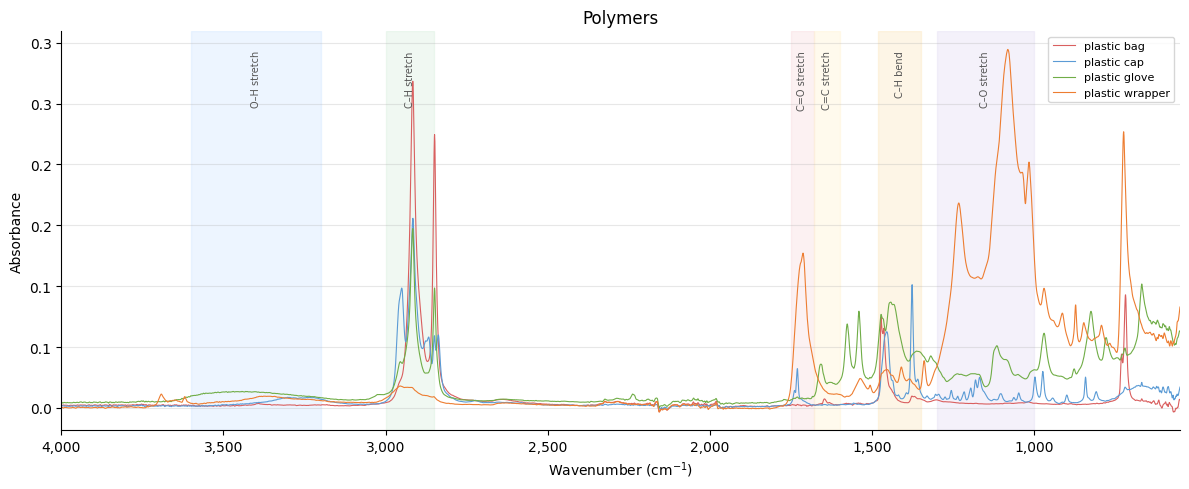

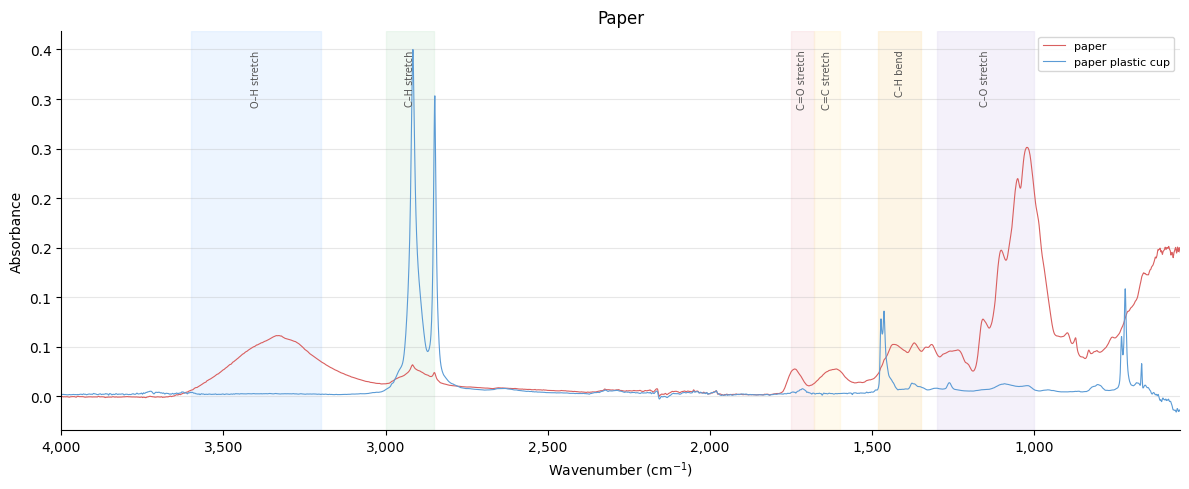

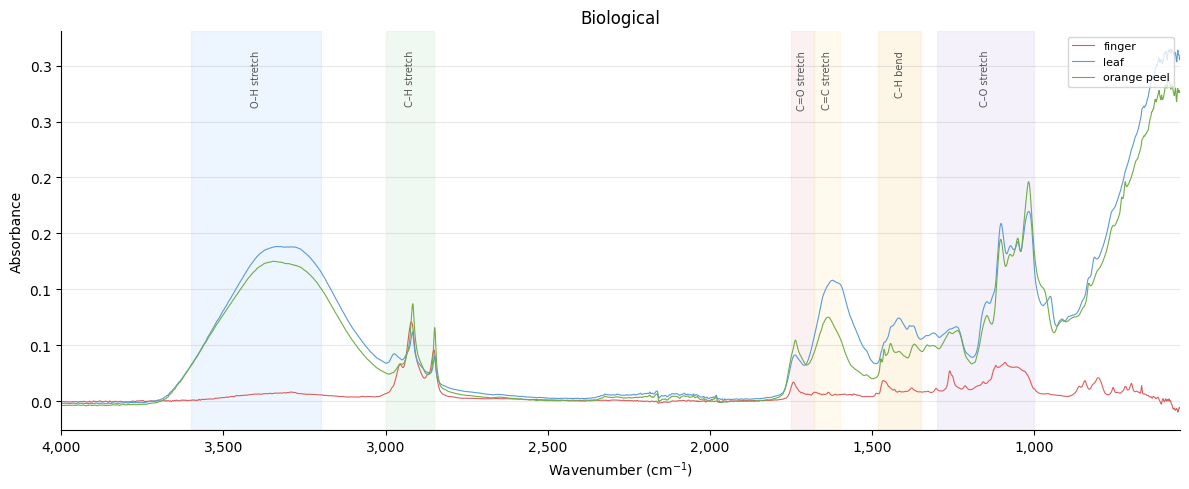

In [5]:
HOUSEHOLD = {
    'Solvents':      (['acetone', 'isopropanol', 'water'], 'solvents'),
    'Food / Minerals': (['coffee', 'salt', 'sugar'], 'food_minerals'),
    'Personal Care': (['soap', 'shampoo', 'conditioner', 'lotion', 'sunscreen', 'cleaner'], 'personal_care'),
    'Polymers':      (['plastic_bag', 'plastic_cap', 'plastic_glove', 'plastic_wrapper'], 'polymers'),
    'Paper':         (['paper', 'paper_plastic_cup'], 'paper'),
    'Biological':    (['finger', 'leaf', 'orange_peel'], 'biological'),
}

for title, (samples, fname) in HOUSEHOLD.items():
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, name in enumerate(samples):
        s = load(name)
        ax.plot(s['wavenumber'], s['absorbance'], linewidth=0.8,
                color=COLORS[i % len(COLORS)], label=name.replace('_', ' '))
    annotate(ax)
    fmt(ax)
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    save(f'images/{fname}_spectrum.png')
    plt.show()

## 6. Chemical Categories

Regrouping the same 23 samples by their dominant spectral features rather than household origin. Samples that look similar on an IR spectrum end up in the same group — regardless of what they are.

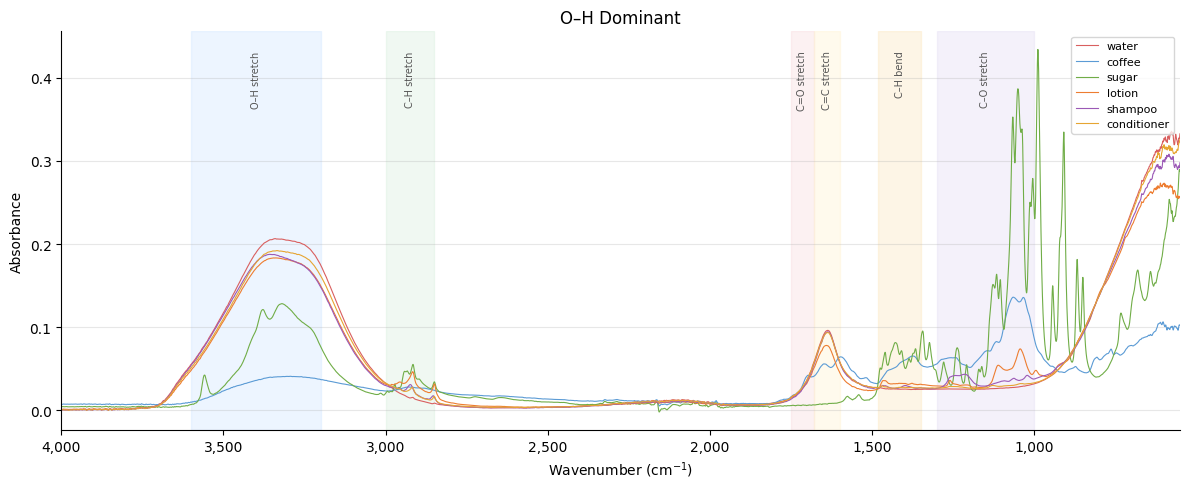

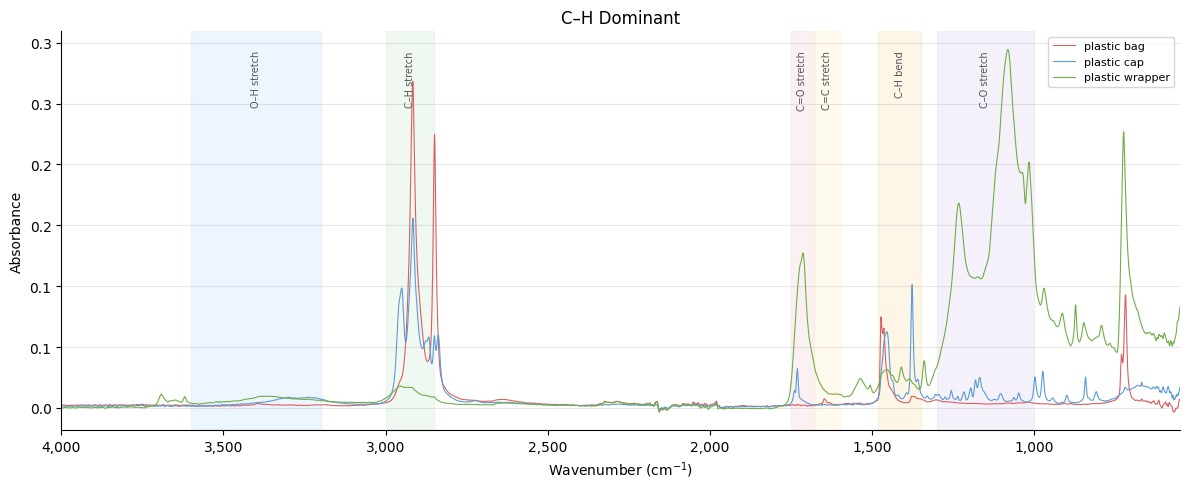

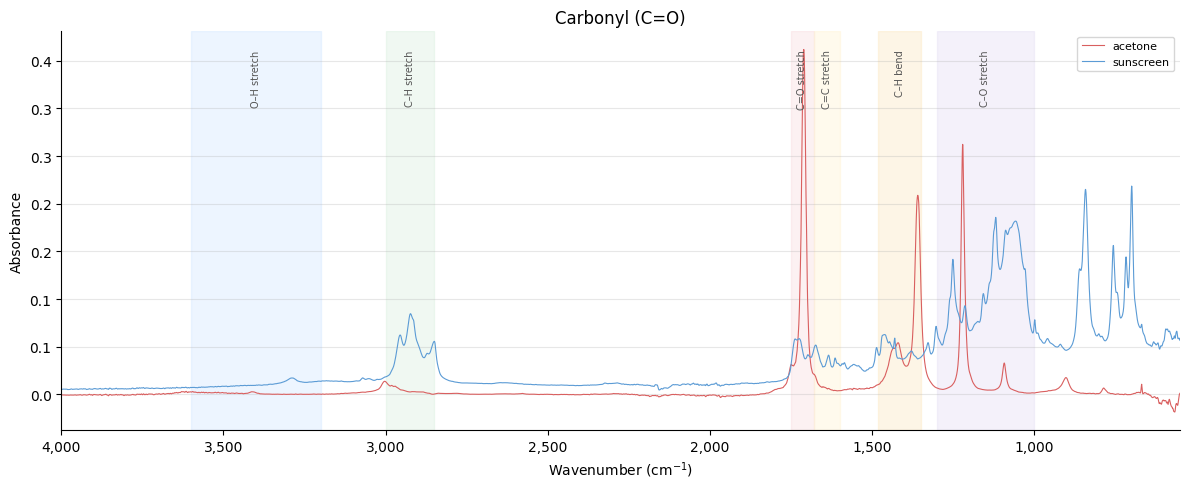

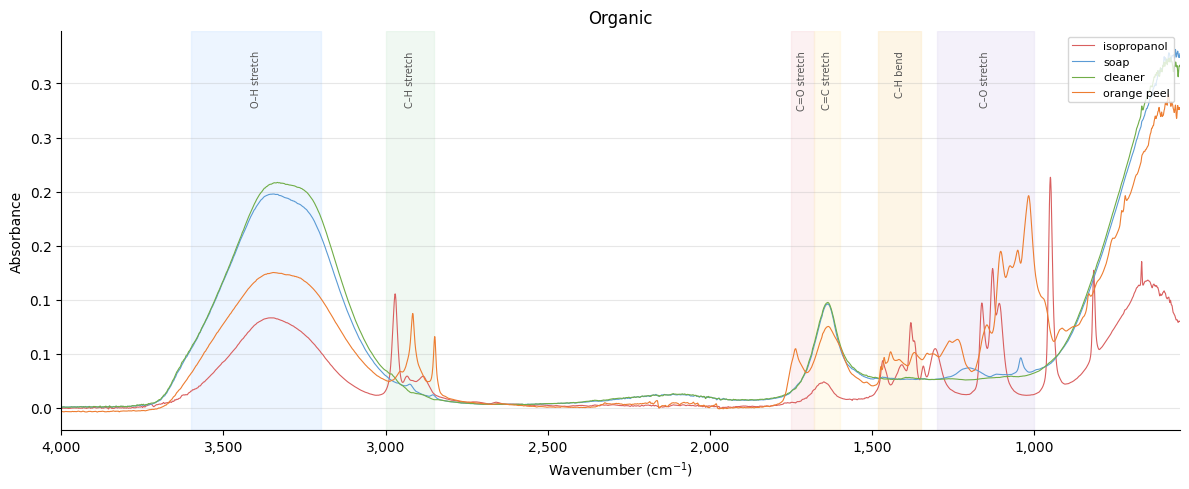

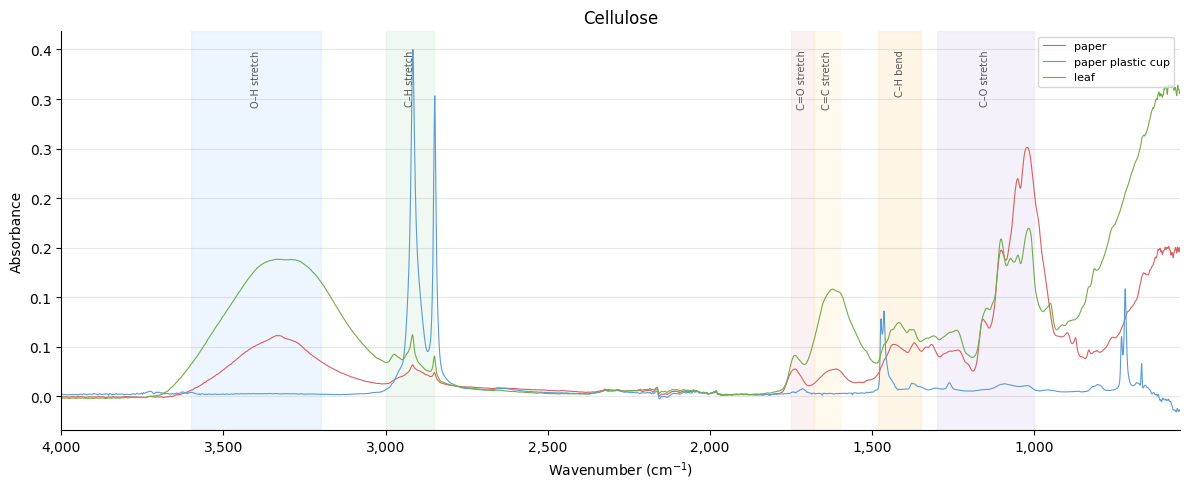

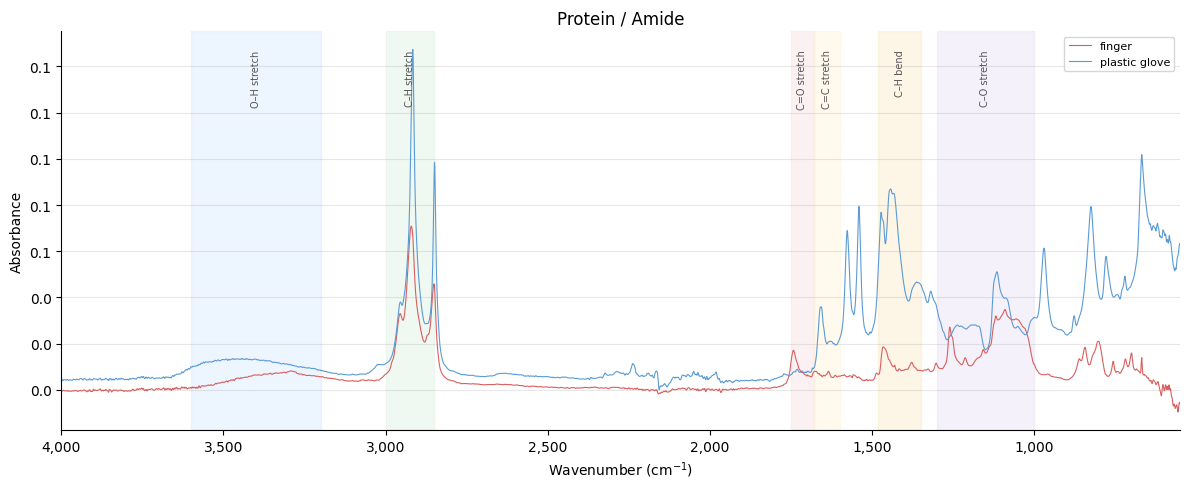

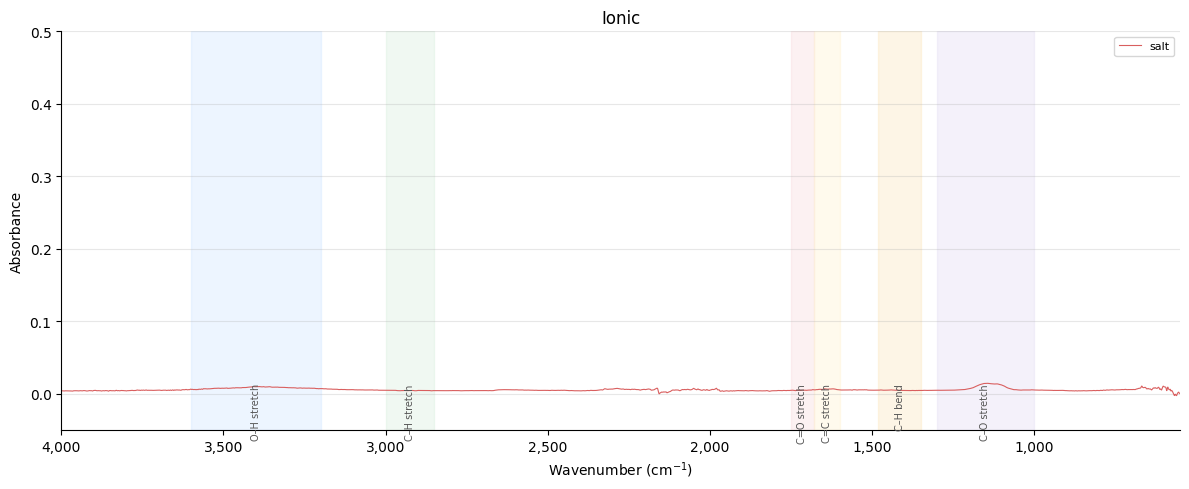

In [6]:
CHEM_CATS = {
    'O–H Dominant':    (['water', 'coffee', 'sugar', 'lotion', 'shampoo', 'conditioner'], 'chem_oh'),
    'C–H Dominant':    (['plastic_bag', 'plastic_cap', 'plastic_wrapper'], 'chem_ch'),
    'Carbonyl (C=O)':  (['acetone', 'sunscreen'], 'chem_co'),
    'Organic':         (['isopropanol', 'soap', 'cleaner', 'orange_peel'], 'chem_mixed'),
    'Cellulose':       (['paper', 'paper_plastic_cup', 'leaf'], 'chem_cellulose'),
    'Protein / Amide': (['finger', 'plastic_glove'], 'chem_protein'),
    'Ionic':           (['salt'], 'chem_ionic'),
}

for title, (samples, fname) in CHEM_CATS.items():
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, name in enumerate(samples):
        s = load(name)
        ax.plot(s['wavenumber'], s['absorbance'], linewidth=0.8,
                color=COLORS[i % len(COLORS)], label=name.replace('_', ' '))
    annotate(ax)
    fmt(ax)
    if fname == 'chem_ionic':
        ax.set_ylim(-0.05, 0.5)
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    save(f'images/{fname}_spectrum.png')
    plt.show()

---

<a href="https://colab.research.google.com/github/vivianweidai/science/blob/main/research/projects/20260415%20IR%20Spectroscopy/output/ir_analysis.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>